In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
import scipy.integrate
from scipy.special import erf
import natural_units as nu
import matplotlib.ticker as ticker

In [2]:
vesc    = 544.0 * nu.km / nu.sec
v0      = 238.0 * nu.km / nu.sec
v_Earth = 250.2 * nu.km / nu.sec

# DM speed distribution
Nesc = np.pi * v0 * v0 * (np.sqrt(np.pi) * v0 * erf(vesc / v0) - 2 * vesc * np.exp(-vesc * vesc / v0 / v0))
def f_halo(v, vEarth = v_Earth):
	return np.pi * v * v0 * v0 / Nesc / vEarth * (2 * np.exp(-(v * v + vEarth * vEarth) / v0 / v0) * np.sinh(2 * v * vEarth / v0 / v0) + (np.exp(-np.power(v + vEarth, 2.0) / v0 / v0) - np.exp(-vesc * vesc / v0 / v0)) * np.heaviside(np.abs(v + vEarth) - vesc, 0) - (np.exp(-np.power(v - vEarth, 2.0) / v0 / v0) - np.exp(-vesc * vesc / v0 / v0)) * np.heaviside(np.abs(v - vEarth) - vesc, 0))

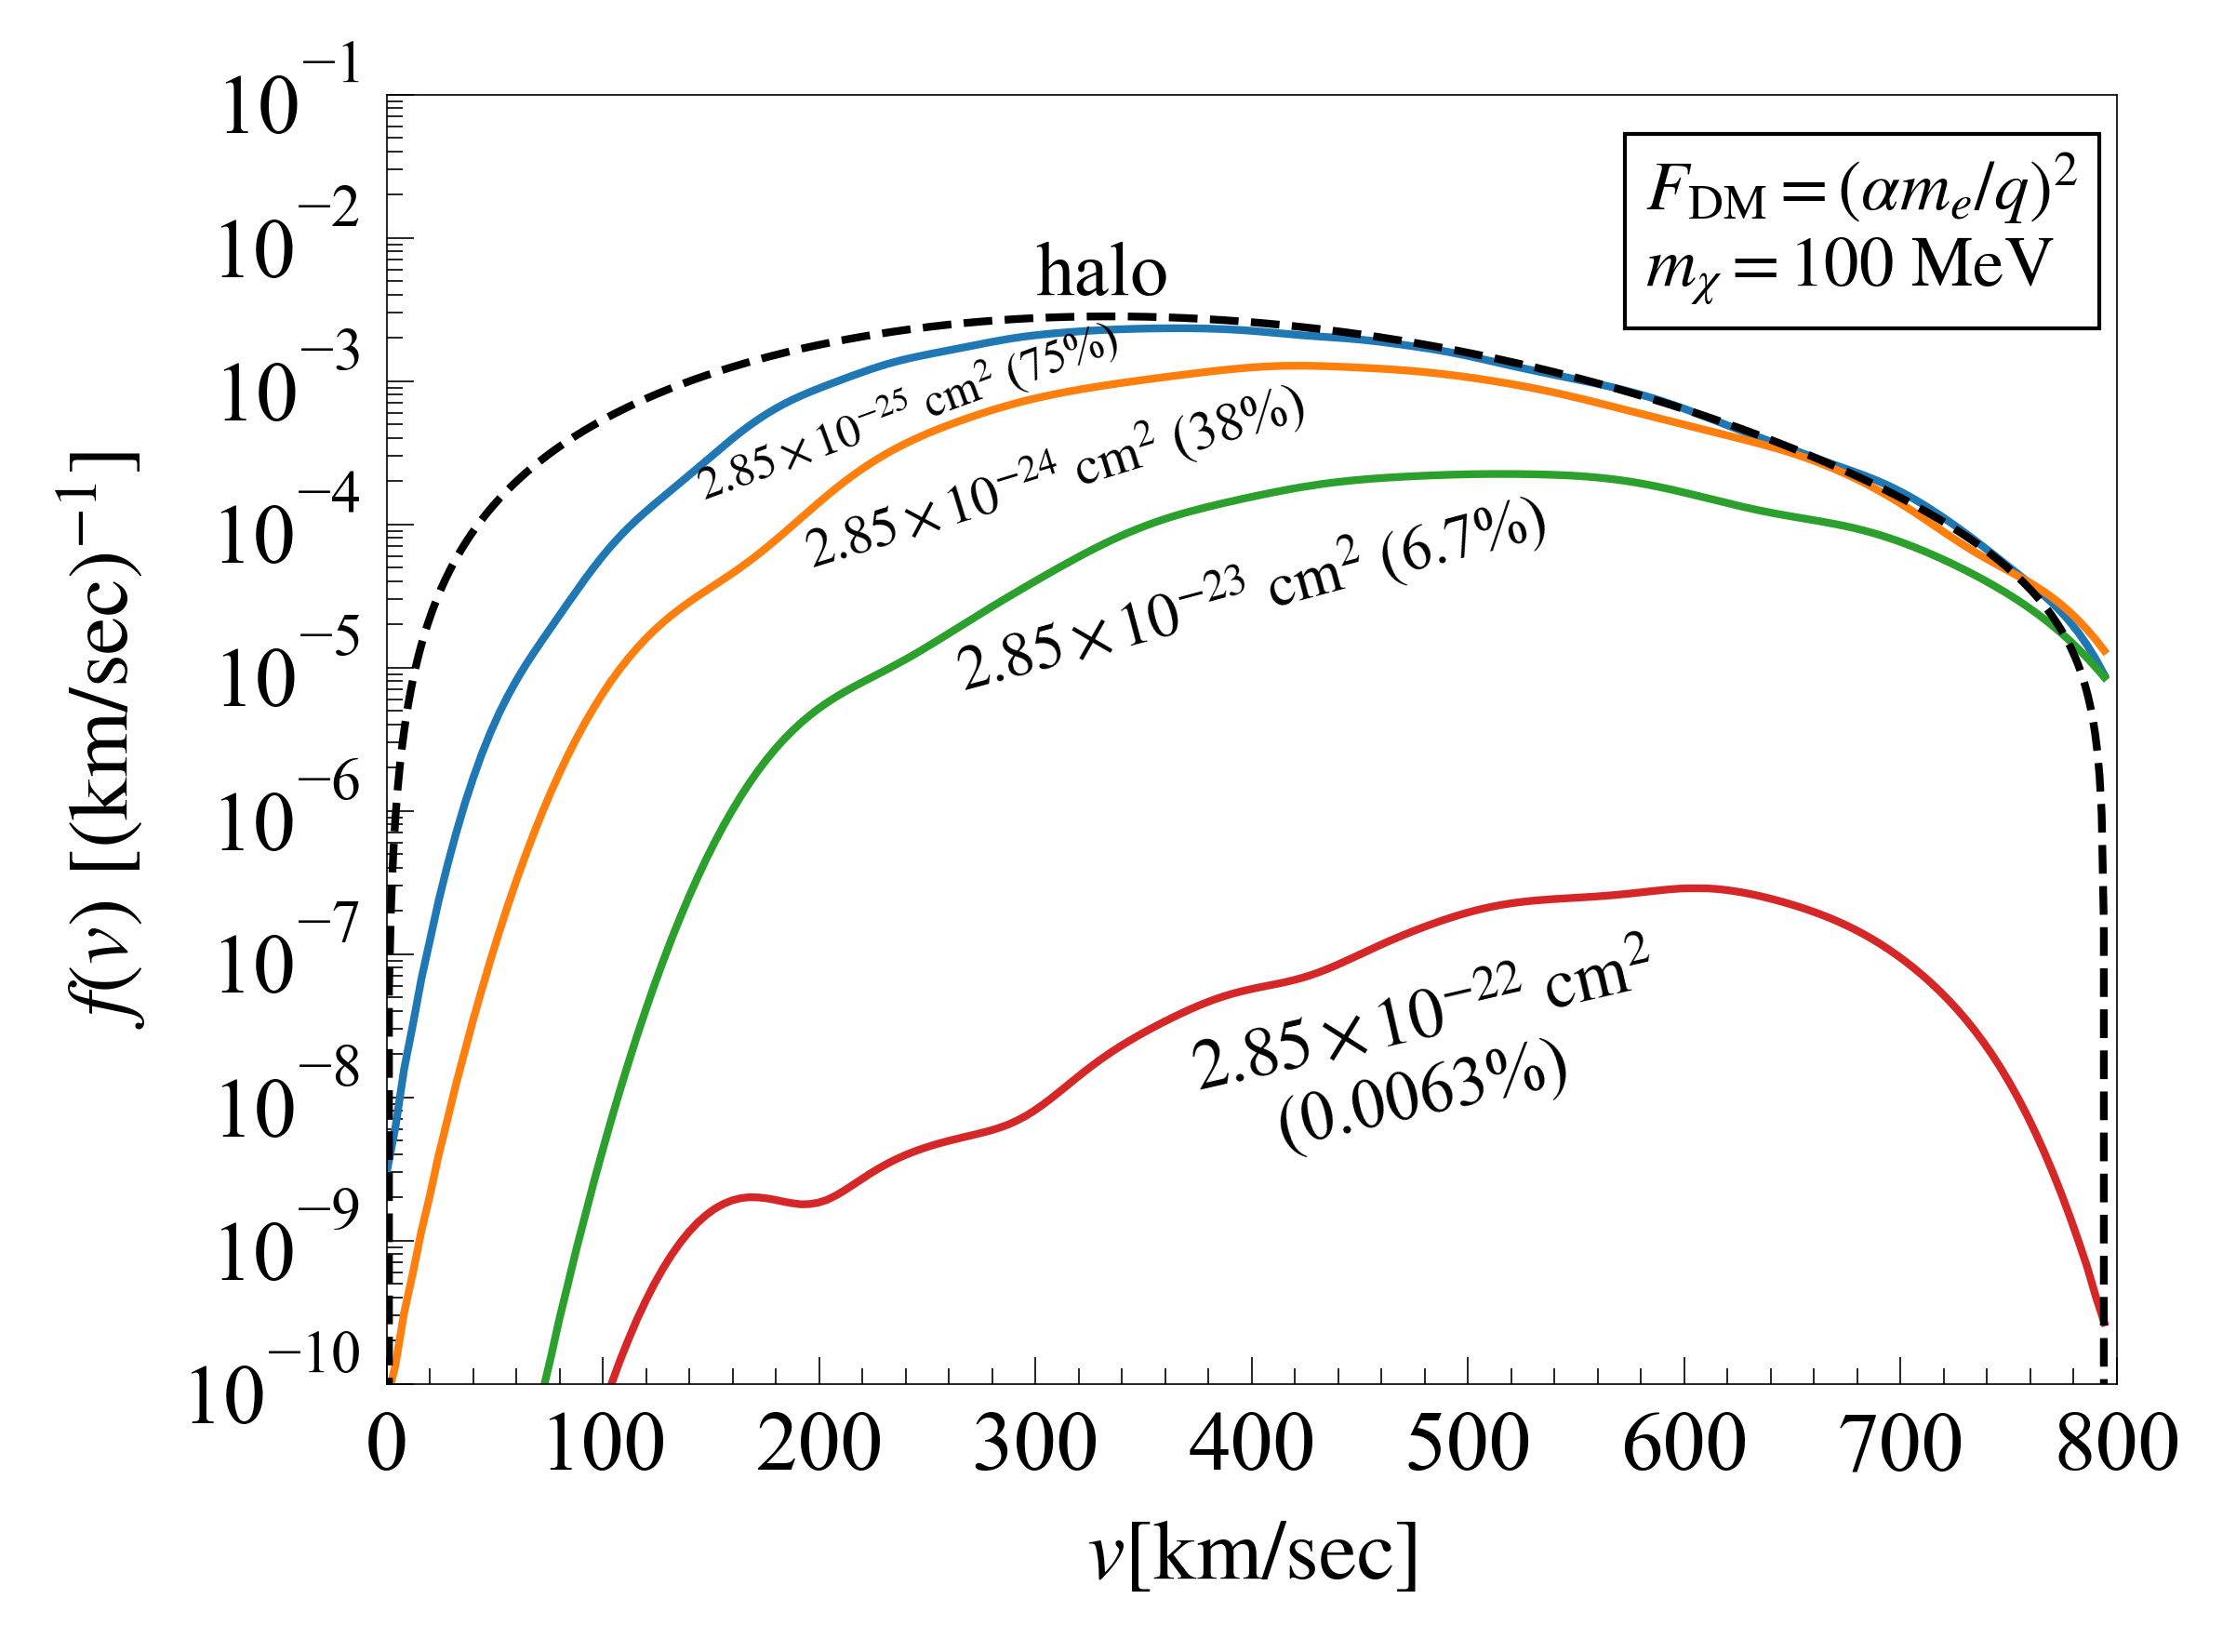

In [3]:
d1 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.1_GeV_sigma=2.84519e-25_cm2_vMin=0_kps.txt')
d2 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.1_GeV_sigma=2.84519e-24_cm2_vMin=0_kps.txt')
d3 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.1_GeV_sigma=2.84519e-23_cm2_vMin=0_kps.txt')
d4 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.1_GeV_sigma=2.84519e-22_cm2_vMin=0_kps.txt')
norm1 = scipy.integrate.simpson(d1[:,1], x = d1[:,0])
norm2 = scipy.integrate.simpson(d2[:,1], x = d2[:,0])
norm3 = scipy.integrate.simpson(d3[:,1], x = d3[:,0])
norm4 = scipy.integrate.simpson(d4[:,1], x = d4[:,0])

v_sample = np.arange(0, 800, 1)

fig, ax = plt.subplots(figsize=(4, 3),dpi = 600)
fontsize = 11

ax.semilogy(d1[:,0] / (nu.km / nu.sec), d1[:,1] * (nu.km / nu.sec), linewidth = 1)
ax.semilogy(d2[:,0] / (nu.km / nu.sec), d2[:,1] * (nu.km / nu.sec), linewidth = 1)
ax.semilogy(d3[:,0] / (nu.km / nu.sec), d3[:,1] * (nu.km / nu.sec), linewidth = 1)
ax.semilogy(d4[:,0] / (nu.km / nu.sec), d4[:,1] * (nu.km / nu.sec), linewidth = 1)
ax.semilogy(v_sample, f_halo(v_sample * nu.km / nu.sec) * (nu.km / nu.sec),linestyle='--', color='black', linewidth = 1)
ax.set_ylim(1e-10,1e-1)
ax.set_xlim(0, 800)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlabel(r'$v [\text{km/sec}]$', fontsize=fontsize)
ax.set_ylabel(r'$f(v)$'+' '+r'$[(\text{km/sec})^{-1}]$', fontsize=fontsize)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto', numticks=200))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=False, right=False, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=False, right=False, width = 0.2)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(370, 3.5e-9, r'$2.85\times 10^{-22}$'+' '+r'$\text{cm}^2$' + '\n    (0.0063%)', fontsize=9, color='black',rotation=13)
ax.text(260, 7e-6, r'$2.85\times 10^{-23}$'+' '+r'$\text{cm}^2$' + ' (6.7%)', fontsize=8, color='black',rotation=15)
ax.text(190, 5e-5, r'$2.85\times 10^{-24}$'+' '+r'$\text{cm}^2$' + ' (38%)', fontsize=7, color='black',rotation=17)
ax.text(140, 1.5e-4, r'$2.85\times 10^{-25}$'+' '+r'$\text{cm}^2$' + ' (75%)', fontsize=6, color='black',rotation=20)
ax.text(300, 4e-3, 'halo', fontsize=10, color='black',rotation=0)
ax.text(582, 4.6e-3, r'$F_{\text{DM}}=(\alpha m_e/q)^2$' + '\n' + r'$m_{\chi} = 100~\text{MeV}$', fontsize=9, 
        color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.savefig("shielded_speed_distribution.pdf", format="pdf",bbox_inches="tight")
plt.show()

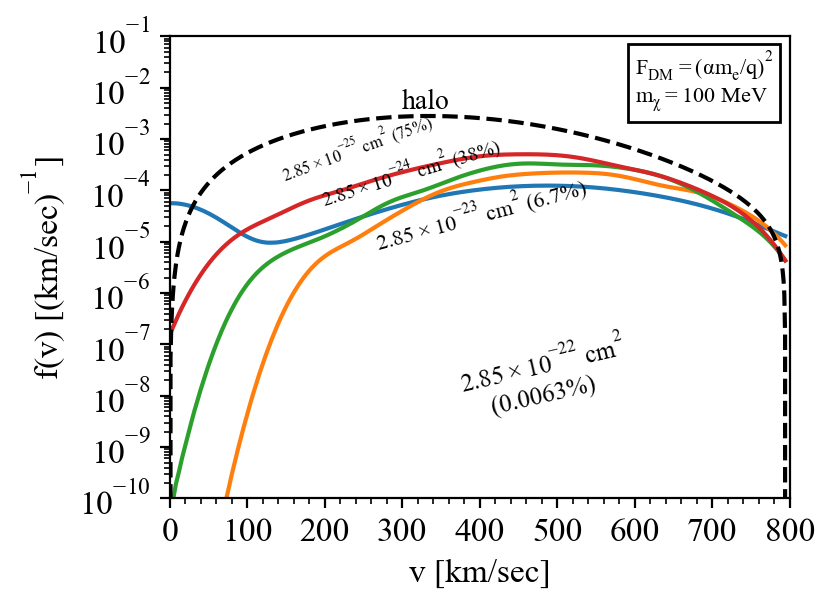

In [4]:
d1 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.01_GeV_sigma=2.40009e-24_cm2_vMin=0_kps.txt')
d2 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.1_GeV_sigma=2.84519e-23_cm2_vMin=0_kps.txt')
d3 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=1_GeV_sigma=5.49433e-22_cm2_vMin=0_kps.txt')
d4 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=10_GeV_sigma=6.5876e-21_cm2_vMin=0_kps.txt')
norm1 = scipy.integrate.simpson(d1[:,1], x = d1[:,0])
norm2 = scipy.integrate.simpson(d2[:,1], x = d2[:,0])
norm3 = scipy.integrate.simpson(d3[:,1], x = d3[:,0])
norm4 = scipy.integrate.simpson(d4[:,1], x = d4[:,0])

v_sample = np.arange(0, 800, 1)

fig, ax = plt.subplots(figsize=(4, 3),dpi = 200)
fontsize = 12

ax.semilogy(d1[:,0] / (nu.km / nu.sec), d1[:,1] * (nu.km / nu.sec))
ax.semilogy(d2[:,0] / (nu.km / nu.sec), d2[:,1] * (nu.km / nu.sec))
ax.semilogy(d3[:,0] / (nu.km / nu.sec), d3[:,1] * (nu.km / nu.sec))
ax.semilogy(d4[:,0] / (nu.km / nu.sec), d4[:,1] * (nu.km / nu.sec))
ax.semilogy(v_sample, f_halo(v_sample * nu.km / nu.sec) * (nu.km / nu.sec),linestyle='--', color='black')
ax.set_ylim(1e-10,1e-1)
ax.set_xlim(0, 800)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlabel('v [km/sec]', fontsize=fontsize)
ax.set_ylabel(r'$f(v)$'+' '+r'$[(km/sec)^{-1}]$', fontsize=fontsize)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto', numticks=200))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.text(370, 3.5e-9, r'$2.85\times 10^{-22}$'+' '+r'$cm^2$' + '\n    (0.0063%)', fontsize=9, color='black',rotation=13)
ax.text(260, 7e-6, r'$2.85\times 10^{-23}$'+' '+r'$cm^2$' + ' (6.7%)', fontsize=8, color='black',rotation=15)
ax.text(190, 5e-5, r'$2.85\times 10^{-24}$'+' '+r'$cm^2$' + ' (38%)', fontsize=7, color='black',rotation=17)
ax.text(140, 1.5e-4, r'$2.85\times 10^{-25}$'+' '+r'$cm^2$' + ' (75%)', fontsize=6, color='black',rotation=20)
ax.text(300, 4e-3, 'halo', fontsize=10, color='black',rotation=0)
ax.text(600, 5e-3, r'$F_{DM}=(\alpha m_e/q)^2$' + '\n' + r'$m_{\chi} = 100$' + ' ' + r'$MeV$', fontsize=8, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square'))
#plt.savefig("shielded_speed_distribution.pdf", format="pdf",bbox_inches="tight")
plt.show()

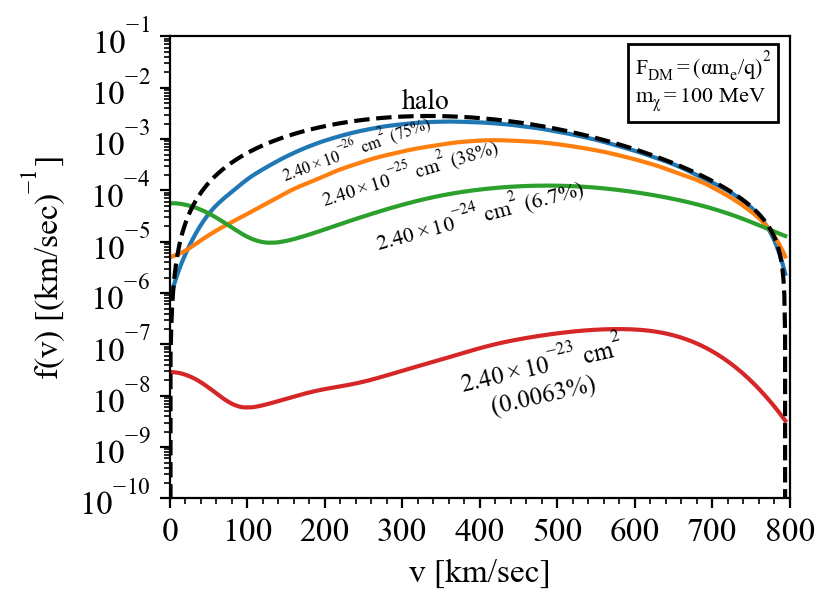

In [158]:
d1 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.01_GeV_sigma=2.40009e-26_cm2_vMin=0_kps.txt')
d2 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.01_GeV_sigma=2.40009e-25_cm2_vMin=0_kps.txt')
d3 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.01_GeV_sigma=2.40009e-24_cm2_vMin=0_kps.txt')
d4 = np.loadtxt('../data/DM_Speed_PDF/DM_Speed_PDF_mDM=0.01_GeV_sigma=2.40009e-23_cm2_vMin=0_kps.txt')
norm1 = scipy.integrate.simpson(d1[:,1], x = d1[:,0])
norm2 = scipy.integrate.simpson(d2[:,1], x = d2[:,0])
norm3 = scipy.integrate.simpson(d3[:,1], x = d3[:,0])
norm4 = scipy.integrate.simpson(d4[:,1], x = d4[:,0])

v_sample = np.arange(0, 800, 1)

fig, ax = plt.subplots(figsize=(4, 3),dpi = 200)
fontsize = 12

ax.semilogy(d1[:,0] / (nu.km / nu.sec), d1[:,1] * (nu.km / nu.sec))
ax.semilogy(d2[:,0] / (nu.km / nu.sec), d2[:,1] * (nu.km / nu.sec))
ax.semilogy(d3[:,0] / (nu.km / nu.sec), d3[:,1] * (nu.km / nu.sec))
ax.semilogy(d4[:,0] / (nu.km / nu.sec), d4[:,1] * (nu.km / nu.sec))
ax.semilogy(v_sample, f_halo(v_sample * nu.km / nu.sec) * (nu.km / nu.sec),linestyle='--', color='black')
ax.set_ylim(1e-10,1e-1)
ax.set_xlim(0, 800)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlabel('v [km/sec]', fontsize=fontsize)
ax.set_ylabel(r'$f(v)$'+' '+r'$[(km/sec)^{-1}]$', fontsize=fontsize)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto', numticks=200))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.text(370, 3.5e-9, r'$2.40\times 10^{-23}$'+' '+r'$cm^2$' + '\n    (0.0058%)', fontsize=9, color='black',rotation=13)
ax.text(260, 7e-6, r'$2.40\times 10^{-24}$'+' '+r'$cm^2$' + ' (4.8%)', fontsize=8, color='black',rotation=15)
ax.text(190, 5e-5, r'$2.40\times 10^{-25}$'+' '+r'$cm^2$' + ' (31%)', fontsize=7, color='black',rotation=17)
ax.text(140, 1.5e-4, r'$2.40\times 10^{-26}$'+' '+r'$cm^2$' + ' (73%)', fontsize=6, color='black',rotation=20)
ax.text(300, 4e-3, 'halo', fontsize=10, color='black',rotation=0)
ax.text(600, 5e-3, r'$F_{DM}=(\alpha m_e/q)^2$' + '\n' + r'$m_{\chi} = 100$' + ' ' + r'$MeV$', fontsize=8, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square'))
plt.savefig("shielded_speed_distribution.pdf", format="pdf",bbox_inches="tight")
plt.show()